## 기본적인 SV 모델 예제

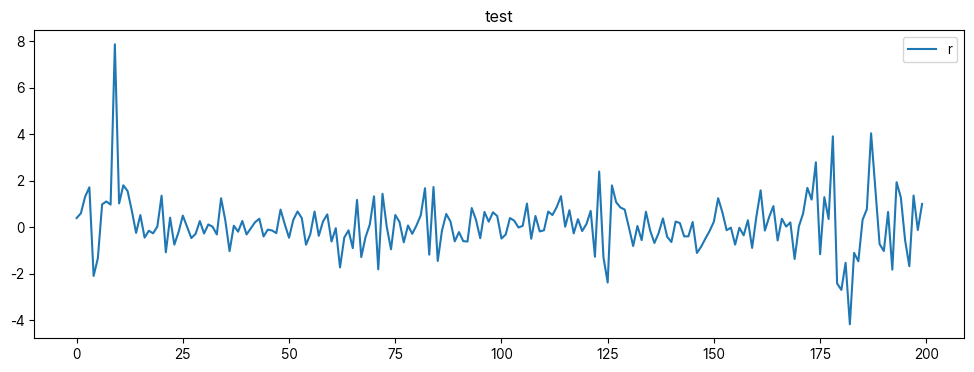

In [36]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

# 예시용 데이터 생성 (or 실제 수익률 사용 가능)
np.random.seed(42)
T = 200
true_phi = 0.95
true_tau = 0.2
true_mu = 0.

log_sigma = np.zeros(T)
log_sigma[0] = np.random.normal(0, true_tau)
for t in range(1, T):
    log_sigma[t] = true_phi * log_sigma[t-1] + np.random.normal(0, true_tau)
sigma = np.exp(log_sigma)
r = true_mu + sigma * np.random.normal(0, 1, T)

# r을 Dataframe으로 변환
ret = pd.DataFrame(r, columns=["r"])

# 시각화
ret.plot(figsize=(12, 4), title="test")
plt.show()


In [ ]:

# PyMC 모델 정의
with pm.Model() as sv_model:
    mu = pm.Normal("mu", 0, 1)
    phi = pm.Beta("phi", alpha=20, beta=1)  # 높은 평균회귀 성향
    tau = pm.Exponential("tau", 1.0)

    log_sigma = pm.GaussianRandomWalk("log_sigma", sigma=tau, shape=T)
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(log_sigma))

    eps = pm.Normal("eps", mu=0, sigma=1, shape=T)
    r_obs = pm.Deterministic("r_obs", mu + sigma_t * eps)

    y_like = pm.Normal("y", mu=mu, sigma=sigma_t, observed=r)

    trace = pm.sample(3000, target_accept=0.99, return_inferencedata=True)


설명
- log_sigma: 잠재 상태 (latent log volatility)
- phi: log-변동성의 자기회귀 계수
- tau: log-변동성의 충격 분산
- sigma_t: 시점별 변동성 (exp로 변환)
- y: 관측된 수익률



In [11]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.035,0.051,-0.058,0.132,0.000,0.000,13871.0,8591.0,1.0
log_sigma[0],0.329,0.440,-0.522,1.135,0.006,0.004,5840.0,8239.0,1.0
log_sigma[1],0.364,0.391,-0.373,1.095,0.005,0.004,5937.0,7579.0,1.0
log_sigma[2],0.432,0.342,-0.202,1.080,0.004,0.003,6110.0,7521.0,1.0
log_sigma[3],0.506,0.305,-0.055,1.076,0.004,0.003,6217.0,7920.0,1.0
...,...,...,...,...,...,...,...,...,...
r_obs[195],0.037,1.565,-2.953,2.988,0.009,0.016,28159.0,8081.0,1.0
r_obs[196],0.034,1.561,-2.896,2.998,0.009,0.016,28945.0,7525.0,1.0
r_obs[197],0.032,1.521,-2.799,2.987,0.009,0.015,30961.0,8883.0,1.0
r_obs[198],0.024,1.507,-2.875,2.885,0.009,0.014,27981.0,9126.0,1.0


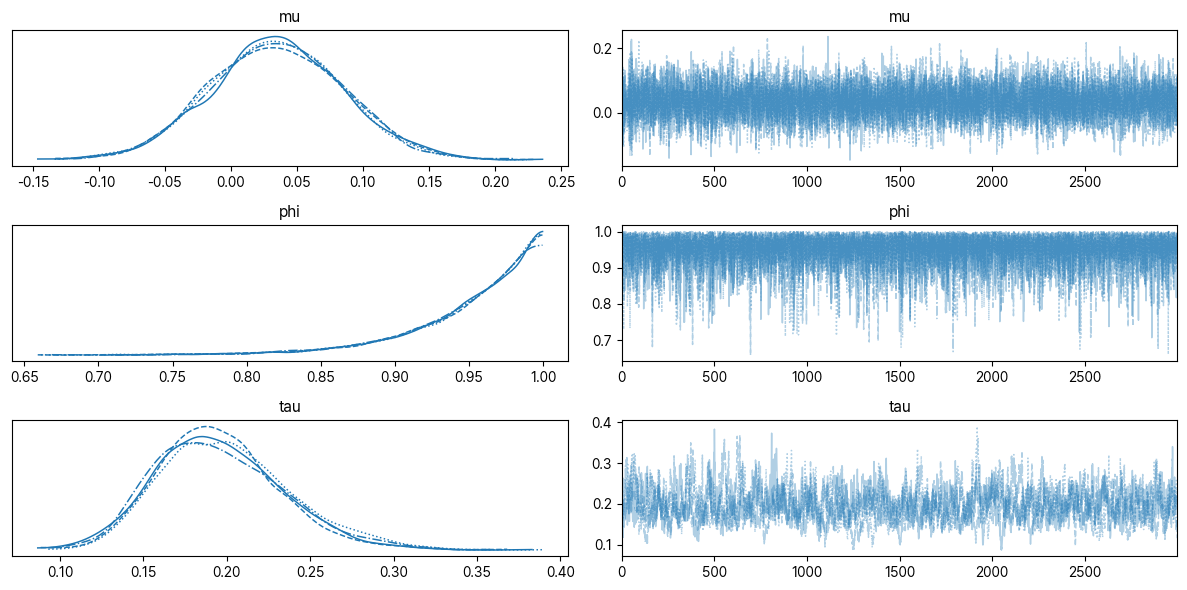

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

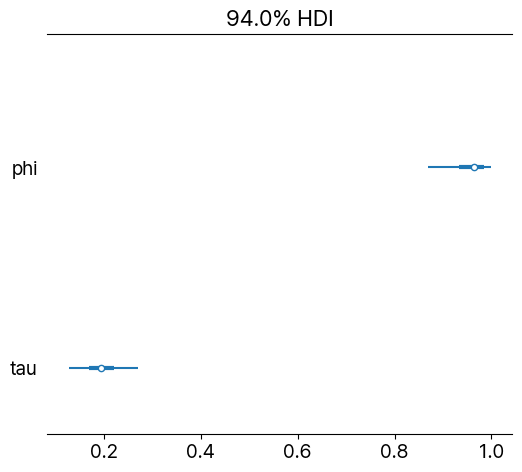

In [12]:
az.plot_trace(trace, var_names=["mu", "phi", "tau"])
plt.tight_layout()
plt.show()

az.plot_forest(trace, var_names=["phi", "tau"], combined=True)


## sp500의 실제 데이터

[*********************100%***********************]  1 of 1 completed


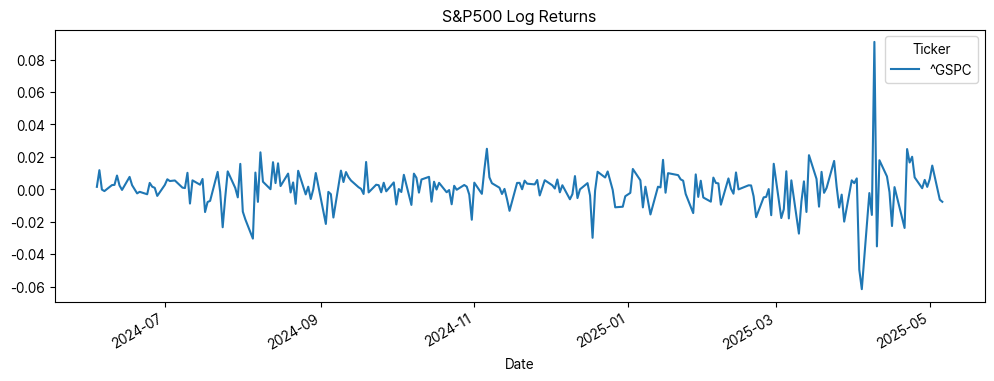

231

In [40]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2024-06-01", auto_adjust=False)
prices = data["Adj Close"].dropna()

# 로그 수익률 계산
log_returns = np.log(prices / prices.shift(1)).dropna()

# 시각화
log_returns.plot(figsize=(12, 4), title="S&P500 Log Returns")
plt.show()

returns = log_returns.values
display(len(returns))

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [49]:
import pymc as pm
import arviz as az

returns = log_returns.values
T = len(returns)

with pm.Model() as sv_model:
    mu = pm.Normal("mu", mu=0, sigma=1)
    phi = pm.Beta("phi", alpha=2, beta=2) 
    tau = pm.Exponential("tau", lam=1)

    log_sigma = pm.GaussianRandomWalk("log_sigma", sigma=tau, shape=T)
    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(log_sigma))

    y = pm.Normal("y", mu=mu, sigma=sigma_t, observed=returns)
    
    # trace = pm.sample(3000, target_accept=0.99, return_inferencedata=True)
    
    trace = pm.sample(
        draws=3000, 
        tune=1000, 
        target_accept=0.95,
        nuts_sampler_kwargs={"max_treedepth": 15},  # PyMC 5.x 방식
        return_inferencedata=True
        )


/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi, tau, log_sigma]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2004 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [50]:
# 추정된 파라미터 확인
az.summary(trace, var_names=["mu", "phi", "tau"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.000,0.000,0.000,0.000,0.000,0.000,13737.0,7533.0,1.00
phi,0.501,0.223,0.119,0.904,0.002,0.002,10792.0,6044.0,1.00
tau,0.001,0.000,0.000,0.002,0.000,0.000,36.0,45.0,1.05


In [45]:
az.to_netcdf(trace, "trace_output.nc")

'trace_output.nc'

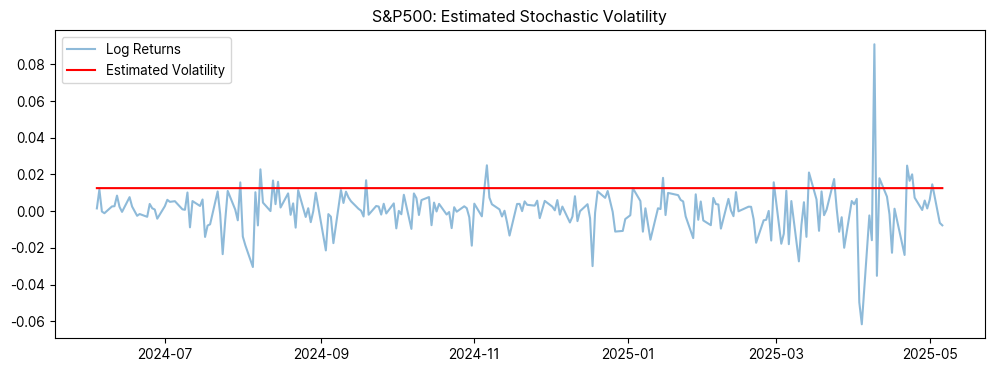

In [46]:

# 잠재 변동성 시각화
plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, returns, label="Log Returns", alpha=0.5)
plt.plot(
    log_returns.index,
    trace.posterior["sigma_t"].mean(dim=("chain", "draw")),
    label="Estimated Volatility",
    color="red"
)
plt.title("S&P500: Estimated Stochastic Volatility")
plt.legend()
plt.show()


In [ ]:
with pm.Model() as jpr_sv_model:
    mu = pm.Normal("mu", mu=0, sigma=10)
    phi = pm.Beta("phi", alpha=2, beta=2)
    sigma_eta = pm.Exponential("sigma_eta", lam=1.0)

    # AR(1) 계수 설정
    rho = phi
    c = (1 - phi) * mu

    # 상태 시계열 h_t: AR(1) with intercept c
    h_raw = pm.AR("h_raw", rho=rho, sigma=sigma_eta, shape=T)
    h = pm.Deterministic("h", c + h_raw)  # h_t = c + phi * h_{t-1} + η_t

    sigma_t = pm.Deterministic("sigma_t", pm.math.exp(h / 2))

    y_obs = pm.Normal("y_obs", mu=0, sigma=sigma_t, observed=returns)

    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)


/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:558: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi, sigma_eta, h_raw]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1089 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [ ]:
# 파라미터 추정 확인
az.plot_trace(trace, var_names=["mu", "phi", "sigma_eta"])
plt.tight_layout()
plt.show()

# 추정된 변동성 시각화
plt.figure(figsize=(12, 4))
plt.plot(log_returns.index, y, label="Observed Log Returns", alpha=0.5)
plt.plot(
    log_returns.index,
    trace.posterior["sigma_t"].mean(dim=("chain", "draw")),
    label="Estimated Volatility (σ_t)",
    color="red"
)
plt.legend()
plt.title("JPR(1994)-style Stochastic Volatility Estimate")
plt.show()


In [68]:
import dis
import re
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# S&P500 지수 다운로드 (티커: ^GSPC)
data = yf.download("^GSPC", start="2024-06-01")
returns = data.loc[:, pd.IndexSlice[:, "^GSPC", :]]
returns.columns = returns.columns.droplevel(1)  # ^GSPC 레벨 제거

returns["change"] = np.log(returns["Close"]).diff()
returns = returns.dropna()
returns = returns[["Close", "change"]]
returns


[*********************100%***********************]  1 of 1 completed


Price,Close,change
Date,,
2024-06-04,5291.339844,0.001502
2024-06-05,5354.029785,0.011778
2024-06-06,5352.959961,-0.000200
2024-06-07,5346.990234,-0.001116
2024-06-10,5360.790039,0.002578
...,...,...
2025-04-30,5569.060059,0.001479
2025-05-01,5604.140137,0.006279
2025-05-02,5686.669922,0.014619


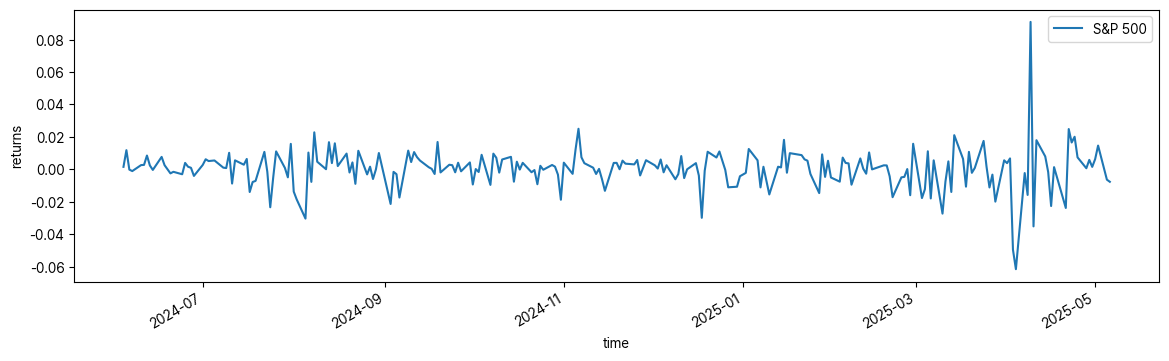

In [69]:
fig, ax = plt.subplots(figsize=(14, 4))
returns.plot(y="change", label="S&P 500", ax=ax)
ax.set(xlabel="time", ylabel="returns")
ax.legend();

In [70]:
def make_stochastic_volatility_model(data):
    with pm.Model(coords={"time": data.index.values}) as model:
        step_size = pm.Exponential("step_size", 10)
        volatility = pm.GaussianRandomWalk("volatility", sigma=step_size, dims="time")
        nu = pm.Exponential("nu", 0.1)
        returns = pm.StudentT(
            "returns", nu=nu, lam=np.exp(-2 * volatility), observed=data["change"], dims="time"
        )
    return model


stochastic_vol_model = make_stochastic_volatility_model(returns)

/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(


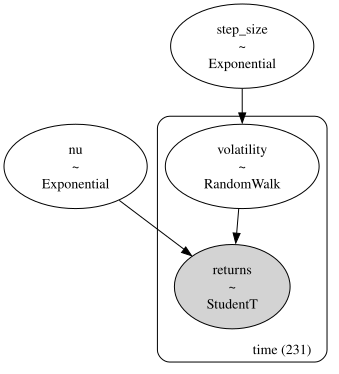

In [71]:
pm.model_to_graphviz(stochastic_vol_model)

In [73]:
rng = np.random.RandomState(1234)
az.style.use("arviz-darkgrid")

In [74]:
with stochastic_vol_model:
    idata = pm.sample_prior_predictive(500, random_seed=rng)

prior_predictive = idata.prior_predictive.stack(pooled_chain=("chain", "draw"))

Sampling: [nu, returns, step_size, volatility]


In [76]:
prior_predictive

<xarray.Dataset>
Dimensions:       (time: 231, pooled_chain: 500)
Coordinates:
  * time          (time) datetime64[ns] 2024-06-04 2024-06-05 ... 2025-05-06
  * pooled_chain  (pooled_chain) object MultiIndex
  * chain         (pooled_chain) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
  * draw          (pooled_chain) int64 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    returns       (time, pooled_chain) float64 7.807e+44 5.289e+39 ... 4.636e-51
Attributes:
    created_at:                 2025-05-07T09:04:32.416308
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0

In [82]:
prior_predictive["returns"].shape

(231, 500)

In [93]:
subset = prior_predictive["returns"].isel(pooled_chain=slice(4, 6, None))

/tmp/ipykernel_1704/1722194205.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


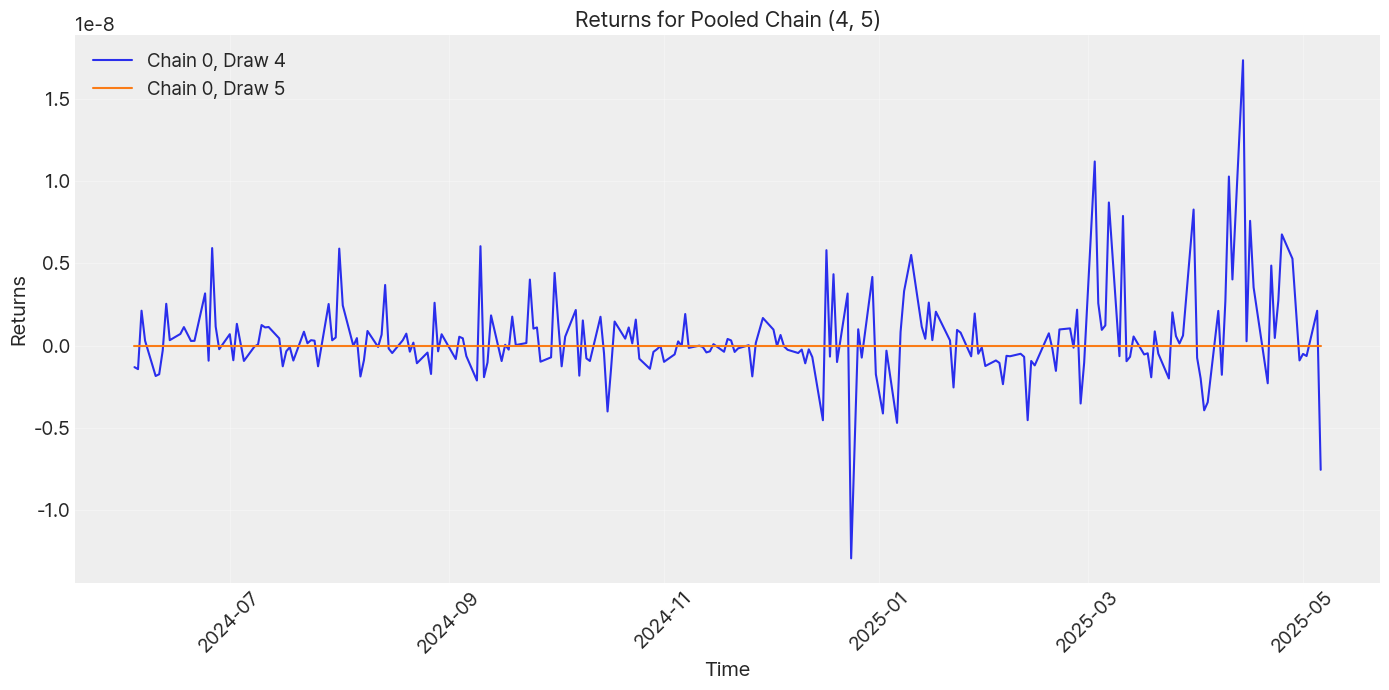

In [ ]:

# 그래프 그리기
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
for i in range(subset.pooled_chain.size):
    chain, draw = subset.pooled_chain.values[i]
    label = f"Chain {chain}, Draw {draw}"
    plt.plot(subset.time, subset[:, i], label=label)

plt.title("Returns for Pooled Chain (4, 5)")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

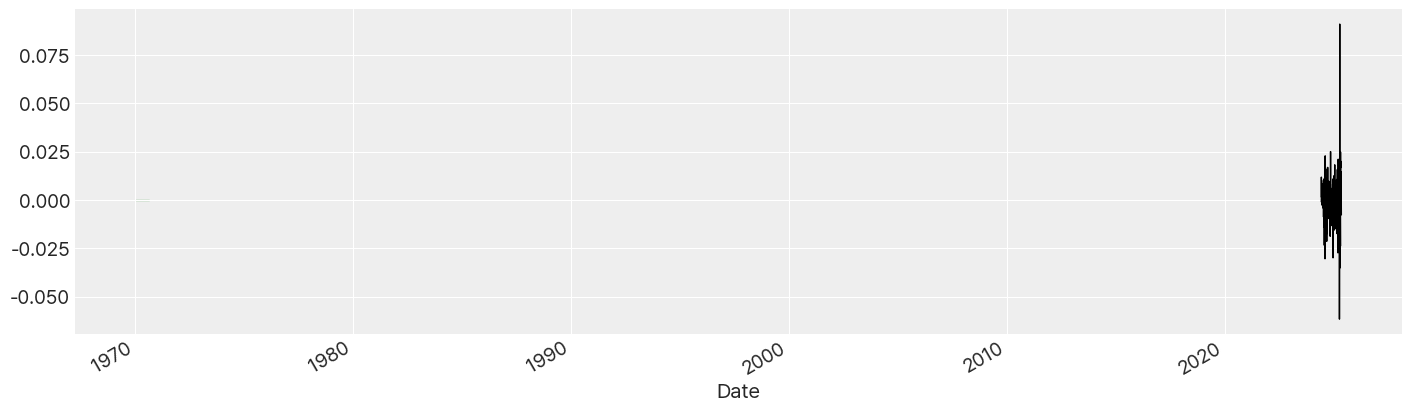

In [86]:
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
ax.plot(
    prior_predictive["returns"].isel(pooled_chain=slice(4, 5, None)),
    "g",
    alpha=0.5,
    lw=1,
    zorder=-10,
)

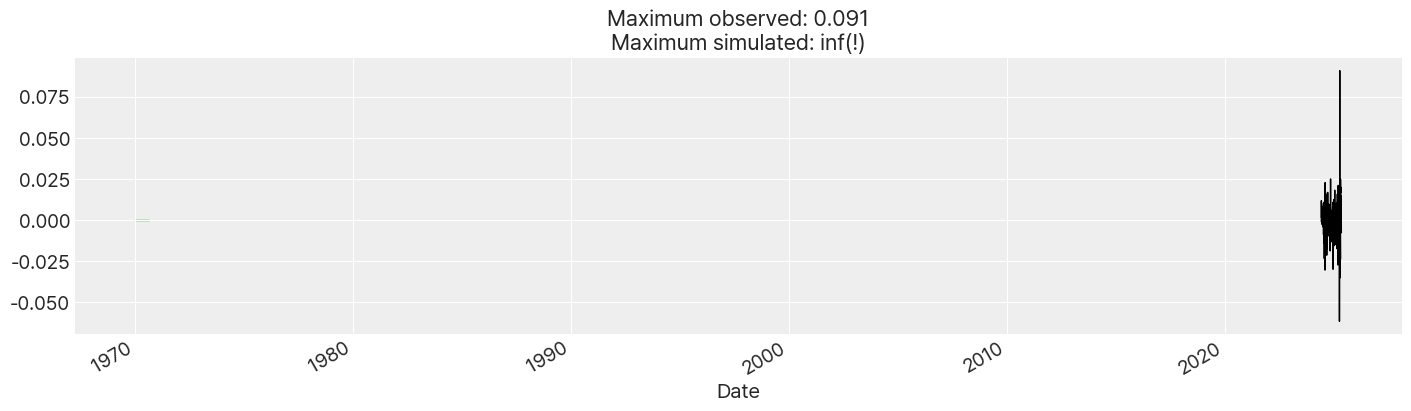

In [75]:
fig, ax = plt.subplots(figsize=(14, 4))
returns["change"].plot(ax=ax, lw=1, color="black")
ax.plot(
    prior_predictive["returns"].isel(pooled_chain=slice(4, 6, None)),
    "g",
    alpha=0.5,
    lw=1,
    zorder=-10,
)

max_observed, max_simulated = np.max(np.abs(returns["change"])), np.max(
    np.abs(prior_predictive["returns"].values)
)
ax.set_title(f"Maximum observed: {max_observed:.2g}\nMaximum simulated: {max_simulated:.2g}(!)");
